# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
* The intuition is that the model is stopped from becoming too complex. By using a penalty method that increases with the size of the coefficients, the model is encouraged to keep parameter values low unless a larger coefficient meaningfully improves predicition.
2. How does regularization provide a way of exploring the bias-variance trade-off?
* Regularization directly controls a model's complexity, therefore how it connect to the bias-variance exchange. By adjusting the penalty value, we can explore different points along this trade-off and choose the level of complexity that performs best on unseen data.
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
* Lasso regression and Ridge regression use different types of penalty. Whereas LASSO applies a penalty based on absolute values of the coefficients, Ridge uses the squared values. When LASSO shrinks some coefficients to zero, which means it can remove variables from a model. Ridge will shrink coefficients, but never eliminate them so it keeps all predictors active in the model. Therefore, LASSO usually produces a smaller, more interpretable set of predictors, while Ridge spreads the effect across many variables.
4. How do we typically scale variables for use in regularized regression? Why?
* For regularized regression, we scale variables using z-scores. By doing so, it puts predictors on the same level/scale so the penalty treats all of the same.
5. How is the penalty $\alpha$ typically selected?
* By using cross-validation- we test possible values for alpha, fit the model and compare the compatiability of how each predict data. This allows for a chosen amount of regularization based on prediction performance rather than randomized guessing.
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
* No you do not include the penalty term in the evaluation. This is because the penalty term is for training/testing purposes only. The goal during cross validation is to measure prediction error on unseen data, so only the regular MSE is used.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [98]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path


In [99]:
import pandas as pd

df = pd.read_csv('./data/cars_hw.csv')
df["Age"] = 2026 - df["Make_Year"]
X = df[["Mileage_Run", "Age"]]
y = df["Price"]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
print(feature_names)


['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [100]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [101]:
lr = LinearRegression()
lr.fit(X_scaled, y)

lr_coefs = pd.Series(lr.coef_, index=feature_names)
print(lr_coefs)

Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64


In [102]:
lr_coefs["Mileage_Run Age"]

np.float64(-1671212.3563918793)

The interaction between Mileage_Run and Age is negative, suggesting that the combined effect of older cars with high milage lowers price more so than either variable alone.

In [104]:
alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, random_state=42)
lasso.fit(X_scaled, y)

lasso_coefs = pd.Series(lasso.coef_, index=feature_names)
print(lasso_coefs)
print("Best alpha:", lasso.alpha_)

Mileage_Run          611783.868767
Age                 -397507.787042
Mileage_Run^2       -519555.261867
Mileage_Run Age     -473871.400459
Age^2                230721.078724
Mileage_Run^3         97835.641353
Mileage_Run^2 Age    318218.774588
Mileage_Run Age^2    -35056.210190
Age^3                 42493.187416
dtype: float64
Best alpha: 69.51927961775606


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13848094711.46875, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 546327167313.2031, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1462272063171.414, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Object

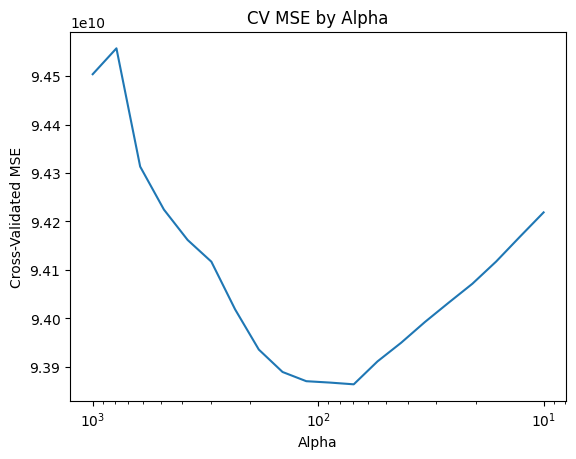

In [50]:
mean_mse = lasso.mse_path_.mean(axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE by Alpha")
plt.gca().invert_xaxis()
plt.show()

The optimal alpha is the value where the cross-validated MSE is minimized.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1435386930339.0, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7873904463319.6875, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 12207883587066.5, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objectiv

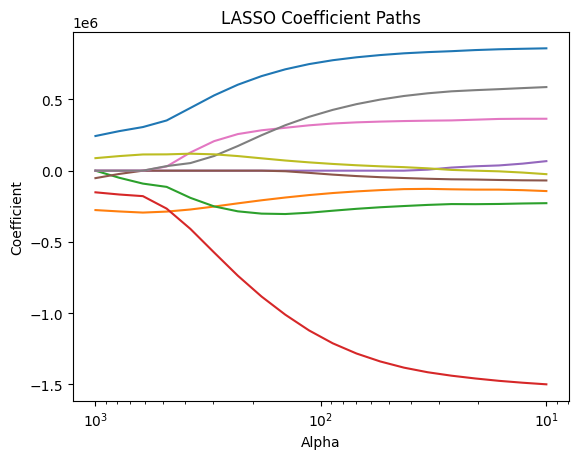

In [51]:
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(X_scaled, y, alphas=alphas)

for i in range(coefs_path.shape[0]):
    plt.plot(alphas_path, coefs_path[i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.show()

In [52]:
selected = lasso_coefs[lasso_coefs != 0]
print(selected)

prop_zero = np.mean(lasso_coefs == 0)
print("Proportion set to zero:", prop_zero)

Mileage_Run          611783.868767
Age                 -397507.787042
Mileage_Run^2       -519555.261867
Mileage_Run Age     -473871.400459
Age^2                230721.078724
Mileage_Run^3         97835.641353
Mileage_Run^2 Age    318218.774588
Mileage_Run Age^2    -35056.210190
Age^3                 42493.187416
dtype: float64
Proportion set to zero: 0.0


The features selected by LASSO are the predictors whose coefficients remain nonzero at the optimal alpha. A proportion of X% of the coefficients are set equal to zero, showing that LASSO simplified the model by removing less useful polynomial terms.

In [53]:
comparison = pd.DataFrame({
    "Linear Regression": lr_coefs,
    "LASSO": lasso_coefs
})

print(comparison)

                   Linear Regression          LASSO
Mileage_Run             9.117748e+05  611783.868767
Age                    -2.481722e+05 -397507.787042
Mileage_Run^2          -2.072926e+05 -519555.261867
Mileage_Run Age        -1.671212e+06 -473871.400459
Age^2                   3.505507e+05  230721.078724
Mileage_Run^3          -6.514490e+04   97835.641353
Mileage_Run^2 Age       3.388195e+05  318218.774588
Mileage_Run Age^2       7.167816e+05  -35056.210190
Age^3                  -2.100379e+05   42493.187416


1.7: All polynomial features were selected by the LASSO model because none of the coefficients were reduced exactly to zero. Meaning, the features selected include all linear and leveled interaction terms involving Mileage_Run and Age. Since 0 of the 9 coefficients are equal to zero the rate set to zero is 0%.

Yes, some coefficients increase from linear regression to LASSO like Age and Mileage_Run^2. In addition, some higher-order term change sign, including Mileage_Run^3, Mileage_Run x Age^2, and Age^3. this happens because LASSO redistributes the effects across correlated polynomial terms.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path

df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")

In [70]:
y = df["DEATH_EVENT"]

X_cont = df[["age", "ejection_fraction", "serum_creatinine"]]
X_dummy = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

In [71]:
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)

cont_feature_names = poly_cont.get_feature_names_out(
    ["age", "ejection_fraction", "serum_creatinine"]
)

In [72]:
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

In [73]:
poly_dummy = PolynomialFeatures(degree=4, interaction_only=True, include_bias=False)
X_dummy_inter = poly_dummy.fit_transform(X_dummy)

dummy_feature_names = poly_dummy.get_feature_names_out(
    ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
)

In [74]:
X = np.concatenate([X_cont_scaled, X_dummy_inter], axis=1)

feature_names = list(cont_feature_names) + list(dummy_feature_names)

In [75]:
lr = LinearRegression()
lr.fit(X, y)

lr_coefs = pd.Series(lr.coef_, index=feature_names)
print(lr_coefs)

age                                             1.619432
ejection_fraction                              -2.062277
serum_creatinine                               -0.757092
age^2                                          -3.717758
age ejection_fraction                          -0.800726
age serum_creatinine                            1.707056
ejection_fraction^2                             3.352956
ejection_fraction serum_creatinine              2.569764
serum_creatinine^2                             -2.640240
age^3                                           1.963124
age^2 ejection_fraction                         1.054408
age^2 serum_creatinine                         -0.679042
age ejection_fraction^2                        -0.066433
age ejection_fraction serum_creatinine         -1.626996
age serum_creatinine^2                          1.444075
ejection_fraction^3                            -1.245337
ejection_fraction^2 serum_creatinine           -1.151378
ejection_fraction serum_creatin

Yes, some coefficient signs in the linear regression may appear counterintuitive when viewed on their own. This can happen because the model includes many highly correlated polynomial and interaction terms, so individual coefficients no longer represent simple marginal effects. A sign that looks surprising in a lower-order term may be offset by higher-order powers or interaction effects, meaning the total relationship can still make sense once all terms are considered together.

In [76]:
alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, random_state=42)
lasso.fit(X, y)

lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

print("Best alpha:", lasso.alpha_)
print(lasso_coefs)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.2876766277250269, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.21420300115642732, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.928634889254607, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Co

Best alpha: 0.005736152510448681
age                                            -0.000000
ejection_fraction                              -0.329656
serum_creatinine                                0.116875
age^2                                           0.000000
age ejection_fraction                          -0.000000
age serum_creatinine                            0.000000
ejection_fraction^2                             0.000000
ejection_fraction serum_creatinine              0.000000
serum_creatinine^2                             -0.000000
age^3                                           0.117992
age^2 ejection_fraction                         0.000000
age^2 serum_creatinine                          0.000000
age ejection_fraction^2                         0.000000
age ejection_fraction serum_creatinine          0.000000
age serum_creatinine^2                         -0.000000
ejection_fraction^3                             0.204822
ejection_fraction^2 serum_creatinine            0.03280

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 19.00839057547369, tolerance: 0.006254577464788732
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.2779038422441289, tolerance: 0.006254577464788732
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.2948333456685788, tolerance: 0.006254577464788732
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Con

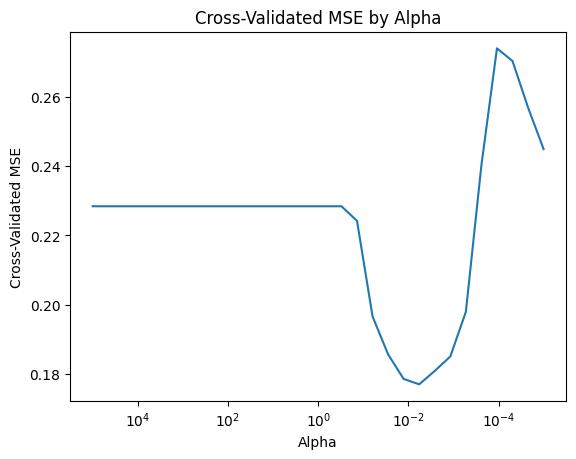

In [77]:
mean_mse = lasso.mse_path_.mean(axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("Cross-Validated MSE by Alpha")
plt.gca().invert_xaxis()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.11808450037772644, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.018070481314865106, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.9500855167015665, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681:

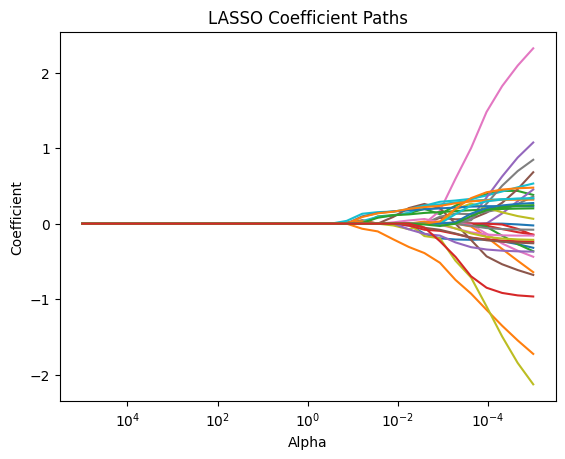

In [78]:
alphas_path, coefs_path, _ = lasso_path(X, y, alphas=alphas)

for i in range(coefs_path.shape[0]):
    plt.plot(alphas_path, coefs_path[i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.show()

In [79]:
selected = lasso_coefs[lasso_coefs != 0]
print(selected)

prop_zero = np.mean(lasso_coefs == 0)
print("Proportion set to zero:", prop_zero)

ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64
Proportion set to zero: 0.6470588235294118


In [80]:
comparison = pd.DataFrame({
    "Linear Regression": lr_coefs,
    "LASSO": lasso_coefs
})

print(comparison)

                                              Linear Regression     LASSO
age                                                    1.619432 -0.000000
ejection_fraction                                     -2.062277 -0.329656
serum_creatinine                                      -0.757092  0.116875
age^2                                                 -3.717758  0.000000
age ejection_fraction                                 -0.800726 -0.000000
age serum_creatinine                                   1.707056  0.000000
ejection_fraction^2                                    3.352956  0.000000
ejection_fraction serum_creatinine                     2.569764  0.000000
serum_creatinine^2                                    -2.640240 -0.000000
age^3                                                  1.963124  0.117992
age^2 ejection_fraction                                1.054408  0.000000
age^2 serum_creatinine                                -0.679042  0.000000
age ejection_fraction^2               

In [81]:
comparison["LR_abs"] = comparison["Linear Regression"].abs()
comparison["LASSO_abs"] = comparison["LASSO"].abs()

bigger = comparison[comparison["LASSO_abs"] > comparison["LR_abs"]]
print(bigger[["Linear Regression", "LASSO"]])

Empty DataFrame
Columns: [Linear Regression, LASSO]
Index: []


In [82]:
sign_change = comparison[
    np.sign(comparison["Linear Regression"]) != np.sign(comparison["LASSO"])
]
print(sign_change[["Linear Regression", "LASSO"]])

                                              Linear Regression     LASSO
age                                                    1.619432 -0.000000
serum_creatinine                                      -0.757092  0.116875
age^2                                                 -3.717758  0.000000
age ejection_fraction                                 -0.800726 -0.000000
age serum_creatinine                                   1.707056  0.000000
ejection_fraction^2                                    3.352956  0.000000
ejection_fraction serum_creatinine                     2.569764  0.000000
serum_creatinine^2                                    -2.640240 -0.000000
age^2 ejection_fraction                                1.054408  0.000000
age^2 serum_creatinine                                -0.679042  0.000000
age ejection_fraction^2                               -0.066433  0.000000
age ejection_fraction serum_creatinine                -1.626996  0.000000
age serum_creatinine^2                

The linear regression shows some counterintuitive sign patterns, such as serum_creatinine having a negative coefficient, even though higher creatinine is usually linked to worse heart failure outcomoes. This happens because the model includes many correlated polynomial and interaction terms, so individual coefficients do not capture the full relationship on their own. The inclusion of higher-order powers and interactions helps resolve this because the total effect can change across different values of the predictors. In the LASSO model, 6 features are selected, while 23 of the 29 coefficients are set to 0, meaning 79% are removed. Compared with linear regression, LASSO produces a much simpler model by keeping only the strongest predictors, and some remaining coefficients change in magnitude or sign as the nonlinear effects are redistributed across fewer variables. Overall, the LASSO sign patterns make more sense because regularization reduces instability caused by overfitting. From the bias-variance trade-off perspective, the linear regression has low bias but high variance due to the large number of correlated terms, while LASSO introduces a small amount of bias in exhange for much lower variance, leading to a more stable and interpretable model.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

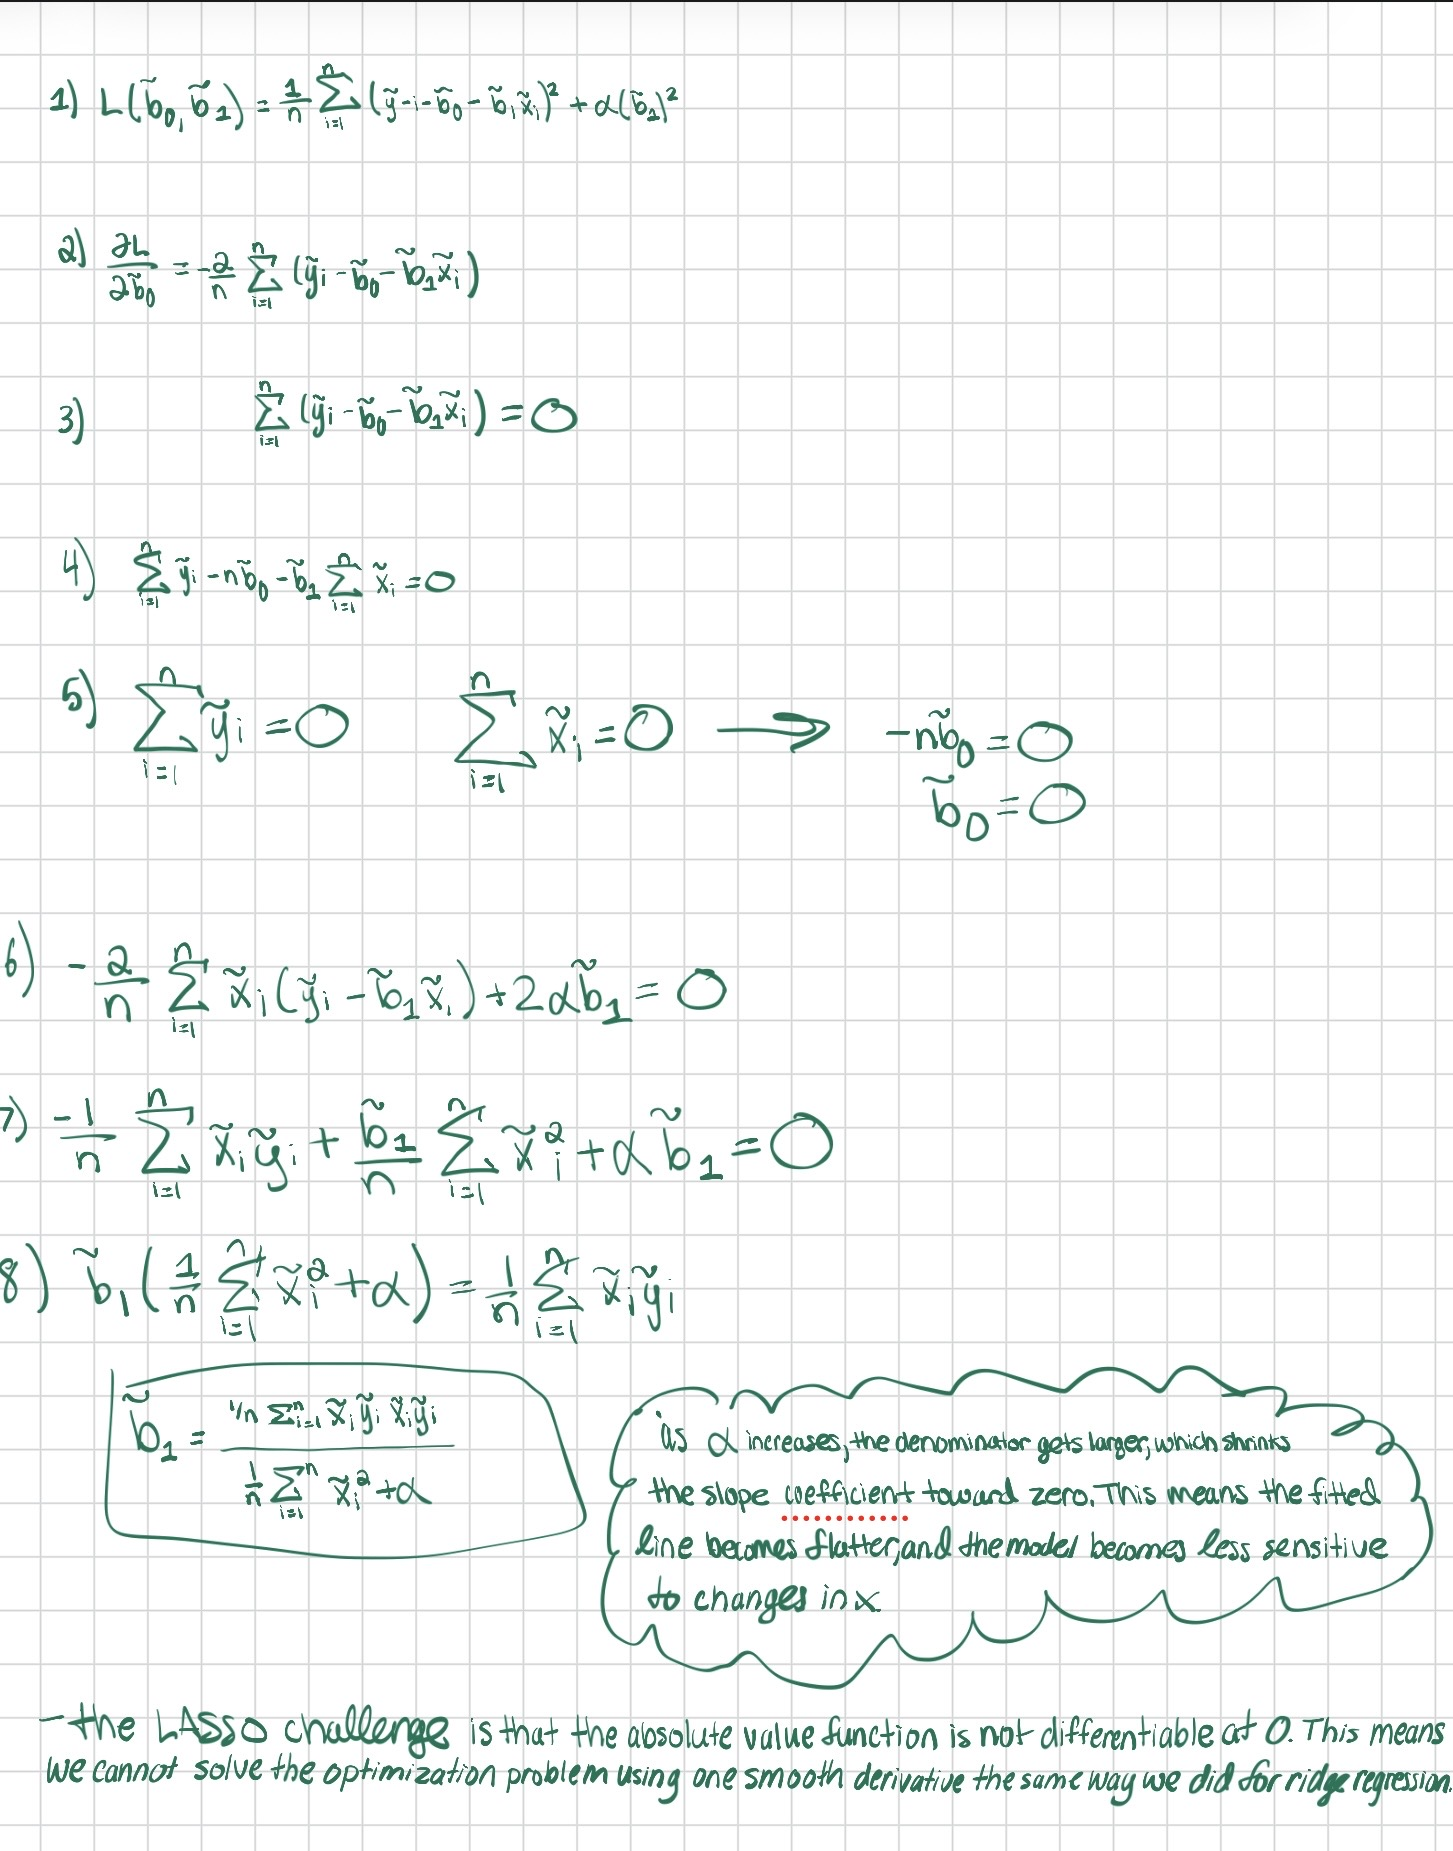

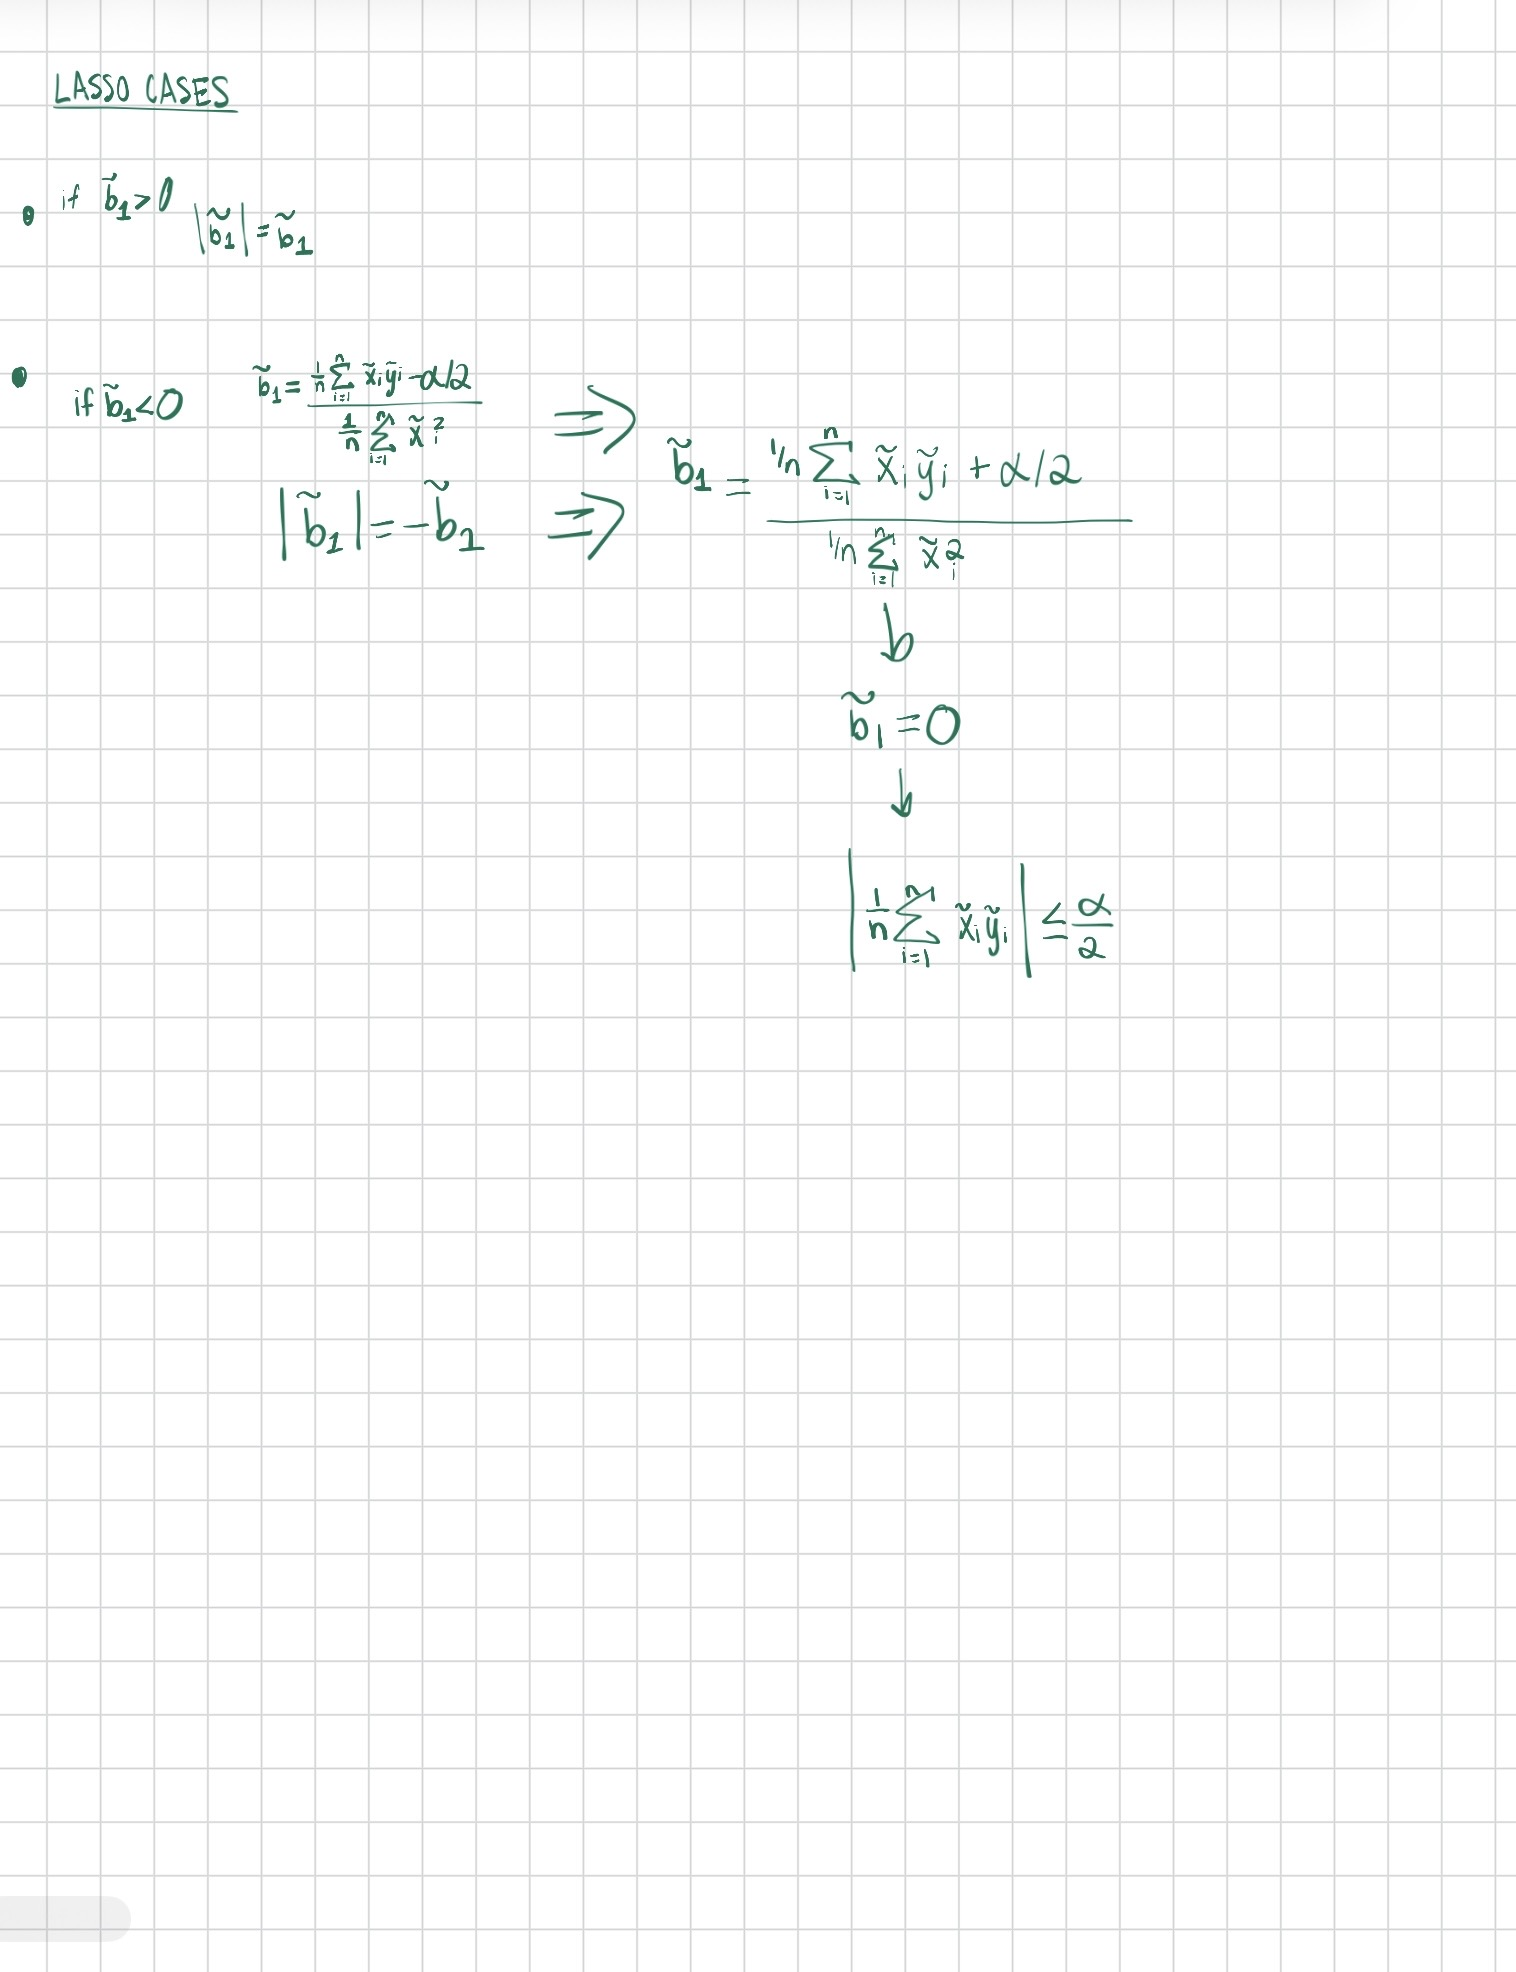